Adınız: Melek
Soyadınız: ÇATAL
Okul Numaranız: 2212721039
GitHub Repo Bağlantısı:  https://github.com/melekcatal/CNN_Siniflandirma.git

# Model 1 – Transfer Learning - VGG16

Bu modelde ImageNet veri seti üzerinde önceden eğitilmiş VGG16 mimarisi kullanılarak,
kendi oluşturduğum iki sınıflı görüntü veri seti üzerinde transfer learning yöntemiyle
sınıflandırma yapılmıştır.




In [2]:
# Bu hücrede veri yükleme, VGG16 modeli, eğitim, değerlendirme ve görselleştirme için gerekli tüm kütüphaneler içe aktarılmaktadır.

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import vgg16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Veri setine erişebilmek için Google Drive Colab ortamına bağlanmaktadır.

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Eğitim, doğrulama ve test klasörlerinin yolları ile görüntü boyutu ve batch size parametreleri tanımlanmıştır.

train_path = '/content/drive/MyDrive/Veriseti/train'
valid_path = '/content/drive/MyDrive/Veriseti/val'
test_path  = '/content/drive/MyDrive/Veriseti/test'

# Ortak parametreler
Img_size = 128
Batch_Size = 32


In [4]:
# VGG16 modeline uygun olacak şekilde preprocess_input fonksiyonu kullanılarak görüntüler normalize edilmektedir.
# Bu modelde veri artırımı kullanılmamıştır.

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)


In [5]:
# Görüntüler klasör yapısına göre otomatik olarak yüklenmiş ve ikili sınıflandırma (binary) problemi olarak tanımlanmıştır.

train_batches = train_gen.flow_from_directory(
    train_path,
    target_size=(Img_size, Img_size),
    batch_size=Batch_Size,
    class_mode='binary'
)

valid_batches = val_gen.flow_from_directory(
    valid_path,
    target_size=(Img_size, Img_size),
    batch_size=Batch_Size,
    class_mode='binary'
)

test_batches = test_gen.flow_from_directory(
    test_path,
    target_size=(Img_size, Img_size),
    batch_size=Batch_Size,
    class_mode='binary',
    shuffle=False
)


Found 112 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 24 images belonging to 2 classes.


In [6]:
# Modelin öğrendiği sınıf isimleri kontrol edilerek doğru klasör yapısının kullanıldığı doğrulanmaktadır.

class_labels = list(train_batches.class_indices.keys())
class_labels


['fare_disi', 'kelebek']

## Model 1 – Transfer Learning Açıklaması

Bu çalışmada sıfırdan bir CNN eğitmek yerine, ImageNet veri seti üzerinde
önceden eğitilmiş VGG16 mimarisi kullanılmıştır.
**include_top=False** seçeneği ile VGG16'nın sınıflandırma katmanları çıkarılmış,
önceden öğrenilmiş ağırlıklar korunarak (katmanlar dondurularak)
model transfer learning yaklaşımıyla eğitilmiştir.

Bu aşamada yalnızca VGG16 üzerine eklenen tam bağlantılı (Dense) katmanlar
eğitilmiş, böylece küçük veri seti üzerinde aşırı öğrenmenin (overfitting)
önüne geçilmesi hedeflenmiştir.


In [7]:
# ImageNet ağırlıklarıyla eğitilmiş VGG16 modeli, son sınıflandırma katmanları çıkarılarak özellik çıkarıcı olarak kullanılmaktadır.

base_model = vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(Img_size, Img_size, 3),
    pooling='avg'
)

base_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# VGG16’nın önceden öğrendiği ağırlıklar korunarak yalnızca yeni eklenen katmanların eğitilmesi sağlanmaktadır (transfer learning).

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers:
    print(layer.name, layer.trainable)


input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False
global_average_pooling2d False


In [9]:
# Özellik çıkarımından sonra aşırı öğrenmeyi önlemek için Dropout içeren tam bağlantılı katmanlar eklenmiştir.

x = Dense(256, activation='relu')(base_model.output)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
# İkili sınıflandırma problemi için binary_crossentropy kayıp fonksiyonu ve Adam optimizasyonu kullanılmıştır.

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [11]:
# Doğrulama doğruluğu en yüksek olan model otomatik olarak diske kaydedilmektedir.

checkpointer = ModelCheckpoint(
    filepath='model1_best.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)


In [12]:
# Model 10 epoch boyunca eğitilmiş ve her epoch sonunda doğrulama performansı izlenmiştir.

history = model.fit(
    train_batches,
    steps_per_epoch=int(np.ceil(train_batches.samples / Batch_Size)),
    validation_data=valid_batches,
    validation_steps=int(np.ceil(valid_batches.samples / Batch_Size)),
    epochs=10,
    callbacks=[checkpointer],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 55s 14s/step - accuracy: 0.5646 - loss: 2.6157 - val_accuracy: 0.8750 - val_loss: 0.6569
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 9s/step - accuracy: 0.8458 - loss: 0.7056 - val_accuracy: 0.9167 - val_loss: 0.4898
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 8s/step - accuracy: 0.9262 - loss: 0.3871 - val_accuracy: 0.9583 - val_loss: 0.2492
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 44s 9s/step - accuracy: 0.9020 - loss: 0.4160 - val_accuracy: 1.0000 - val_loss: 4.7723e-04
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 8s/step - accuracy: 0.9636 - loss: 0.2667 - val_accuracy: 1.0000 - val_loss: 4.2121e-04
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 41s 8s/step - accuracy: 0.9530 - loss: 0.2357 - val_accuracy: 1.0000 - val_loss: 5.3389e-05
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 41s 8s/step - accuracy: 0.9939 - loss: 0.0107 - val_accuracy: 1.0000 - val_loss: 2.5366e-05
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 45s 9s/step - accuracy: 0.9835 - loss: 0.0222 - val_accuracy: 1.0000 - val_loss

In [13]:
# En iyi doğrulama performansına sahip model yüklenerek test verisi üzerinde başarımı ölçülmüştür.

model.load_weights('model1_best.keras')

test_score = model.evaluate(test_batches, verbose=1)
print("Test doğruluğu:", test_score[1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.9167 - loss: 0.4594
Test doğruluğu: 0.9166666865348816


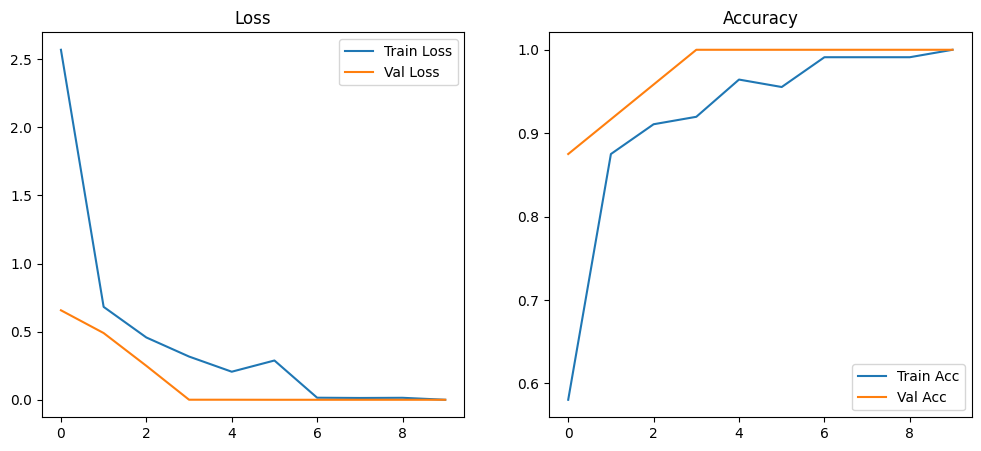

In [14]:
# Modelin eğitim sürecindeki kayıp ve doğruluk değerleri görselleştirilerek öğrenme davranışı analiz edilmiştir.

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


<Figure size 800x600 with 0 Axes>

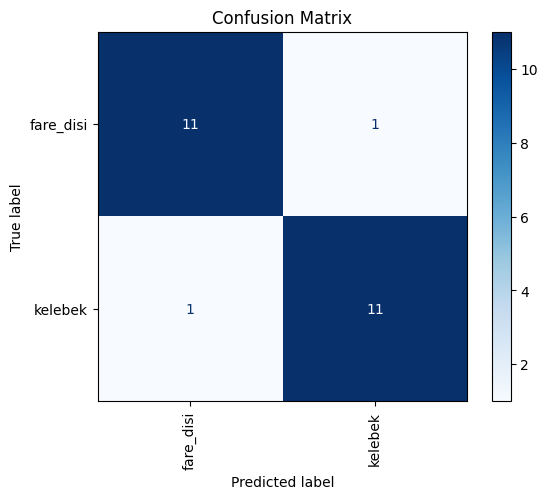

In [15]:
# Test sonuçları üzerinden confusion matrix hesaplanarak sınıflandırma performansı detaylı şekilde incelenmiştir.

predictions = model.predict(test_batches)
predicted_classes = (predictions > 0.5).astype(int).ravel()

true_classes = test_batches.classes
class_labels = list(test_batches.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

plt.figure(figsize=(8,6))
disp.plot(xticks_rotation='vertical', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


Saving WhatsApp Image 2025-12-09 at 00.50.06.jpeg to WhatsApp Image 2025-12-09 at 00.50.06.jpeg


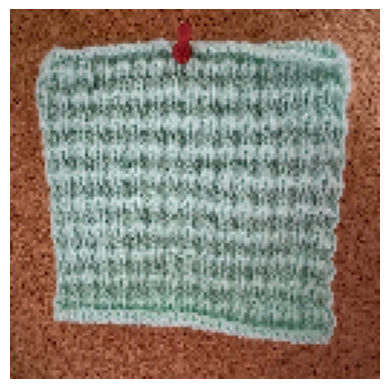

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step
Tahmin edilen sınıf: fare_disi
Olasılık: 5.4380354e-05


In [16]:
# Eğitilen model kullanılarak harici bir görüntü üzerinde sınıf tahmini yapılmıştır.

from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(128,128))
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = model.predict(img_array)[0][0]
class_index = int(prediction > 0.5)

print("Tahmin edilen sınıf:", class_labels[class_index])
print("Olasılık:", prediction)


# Model 1 – Transfer Learning ve Fine-Tuning (VGG16)

Bu modelde ImageNet veri seti üzerinde önceden eğitilmiş VGG16 mimarisi
kullanılarak transfer learning uygulanmıştır.
İlk aşamada VGG16 katmanları dondurulmuş, ikinci aşamada ise son
convolution katmanları açılarak düşük öğrenme oranı ile fine-tuning yapılmıştır.


In [17]:
# Bu hücrede veri yükleme, VGG16 modeli, eğitim, değerlendirme ve görselleştirme için gerekli tüm kütüphaneler içe aktarılmaktadır.

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import vgg16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


In [18]:
# Veri setine erişebilmek için Google Drive Colab ortamına bağlanmaktadır.

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# Eğitim, doğrulama ve test klasörlerinin yolları ile görüntü boyutu ve batch size parametreleri tanımlanmıştır.

train_path = '/content/drive/MyDrive/Veriseti/train'
valid_path = '/content/drive/MyDrive/Veriseti/val'
test_path  = '/content/drive/MyDrive/Veriseti/test'

# Ortak parametreler
Img_size = 128
Batch_Size = 32


In [20]:
# VGG16 modeline uygun olacak şekilde preprocess_input fonksiyonu kullanılarak görüntüler normalize edilmektedir.
# Bu modelde veri artırımı kullanılmamıştır.

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)


In [21]:
# Görüntüler klasör yapısına göre otomatik olarak yüklenmiş ve ikili sınıflandırma (binary) problemi olarak tanımlanmıştır.

train_batches = train_gen.flow_from_directory(
    train_path,
    target_size=(Img_size, Img_size),
    batch_size=Batch_Size,
    class_mode='binary'
)

valid_batches = val_gen.flow_from_directory(
    valid_path,
    target_size=(Img_size, Img_size),
    batch_size=Batch_Size,
    class_mode='binary'
)

test_batches = test_gen.flow_from_directory(
    test_path,
    target_size=(Img_size, Img_size),
    batch_size=Batch_Size,
    class_mode='binary',
    shuffle=False
)


Found 112 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 24 images belonging to 2 classes.


In [22]:
# Modelin öğrendiği sınıf isimleri kontrol edilerek doğru klasör yapısının kullanıldığı doğrulanmaktadır.

class_labels = list(train_batches.class_indices.keys())
class_labels


['fare_disi', 'kelebek']

In [23]:
# ImageNet ağırlıklarıyla eğitilmiş VGG16 modeli, son sınıflandırma katmanları çıkarılarak özellik çıkarıcı olarak kullanılmaktadır.

base_model = vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(Img_size, Img_size, 3),
    pooling='avg'
)

base_model.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# VGG16’nın önceden öğrendiği ağırlıklar korunur, yalnızca yeni katmanlar eğitilir.

for layer in base_model.layers:
    layer.trainable = False


In [25]:
# İkili sınıflandırma için tam bağlantılı katmanlar eklenir.

x = Dense(256, activation='relu')(base_model.output)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [26]:
# Transfer learning aşaması için uygun öğrenme oranı ile model derlenir.

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [27]:
# En yüksek doğrulama başarımına sahip model saklanır.

checkpointer = ModelCheckpoint(
    filepath='model1_best.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)


In [28]:
# Sadece eklenen katmanlar eğitilir.

history = model.fit(
    train_batches,
    validation_data=valid_batches,
    epochs=10,
    callbacks=[checkpointer],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 39s 10s/step - accuracy: 0.6237 - loss: 2.2562 - val_accuracy: 0.9583 - val_loss: 0.2305
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 45s 11s/step - accuracy: 0.9124 - loss: 0.4426 - val_accuracy: 0.9583 - val_loss: 0.0596
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 47s 12s/step - accuracy: 0.9703 - loss: 0.1827 - val_accuracy: 1.0000 - val_loss: 0.0093
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 37s 9s/step - accuracy: 0.9799 - loss: 0.0215 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 40s 10s/step - accuracy: 0.9904 - loss: 0.0206 - val_accuracy: 1.0000 - val_loss: 4.4276e-04
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step - accuracy: 0.9912 - loss: 0.0614 - val_accuracy: 1.0000 - val_loss: 2.2400e-04
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 8s/step - accuracy: 1.0000 - loss: 0.0130 - val_accuracy: 1.0000 - val_loss: 1.4682e-04
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step - accuracy: 0.9964 - loss: 0.0137 - val_accuracy: 1.0000 - val_loss:

## Fine-Tuning Aşaması

Bu aşamada VGG16 mimarisinin son convolution katmanları açılarak
çok düşük öğrenme oranı ile fine-tuning uygulanmıştır.
Amaç, önceden öğrenilmiş genel özellikleri bozmadan
veri setine özgü daha ayırt edici özelliklerin öğrenilmesini sağlamaktır.


In [29]:
# VGG16’nın yalnızca son katmanları açılarak overfitting riski azaltılır.

for layer in base_model.layers[-4:]:
    layer.trainable = True


In [30]:
# Fine-tuning sırasında öğrenme oranı düşürülerek ağırlıkların kontrollü güncellenmesi sağlanır.

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [31]:
# Kısa süreli fine-tuning eğitimi gerçekleştirilir.

fine_tune_history = model.fit(
    train_batches,
    validation_data=valid_batches,
    epochs=5,
    verbose=1
)


Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 35s 8s/step - accuracy: 1.0000 - loss: 9.1654e-04 - val_accuracy: 1.0000 - val_loss: 1.2725e-04
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 7s/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 1.1055e-04
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 9s/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 1.2394e-04
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 36s 9s/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 1.4115e-04
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 9s/step - accuracy: 0.9964 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 6.6468e-05


In [32]:
# Fine-tuning sonrası nihai model başarımı ölçülür.

test_score = model.evaluate(test_batches, verbose=1)
print("Fine-tuning sonrası test doğruluğu:", test_score[1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9583 - loss: 0.0694
Fine-tuning sonrası test doğruluğu: 0.9583333134651184


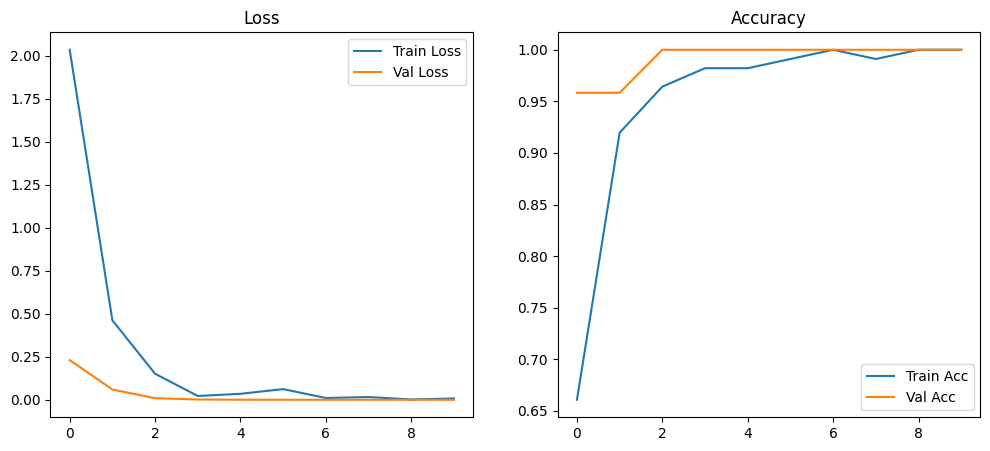

In [33]:
# Eğitim Grafikleri

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


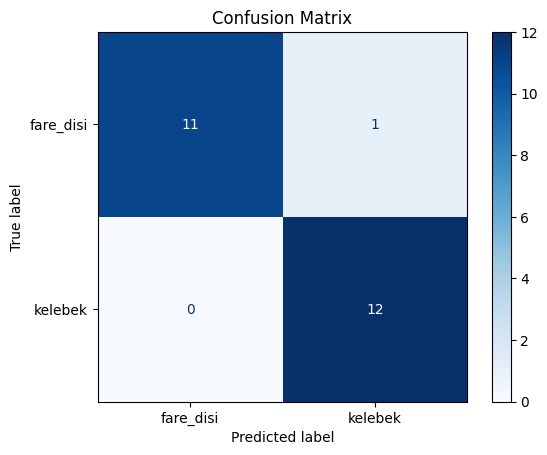

In [34]:
# Confusion Matrix

preds = model.predict(test_batches)
pred_classes = (preds > 0.5).astype(int).ravel()

cm = confusion_matrix(test_batches.classes, pred_classes)
disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
